In [1]:
import pandas as pd

In [21]:
#assign directory
path_1 = "data/mexico-real-estate-1.csv"
path_2 = "data/mexico-real-estate-2.csv"
path_3 = "data/mexico-real-estate-3.csv"

In [3]:
#Assign df1 to read_csv
df1 = pd.read_csv(path_1)

#Perform the 5 Ritual steps of data cleaning
# 1 .Head
# 2 .shape
# 3 .dypes
# 4 .isnull()
# 5 .sum()
# pd.read_csv(...)   The function that reads a CSV file into a DataFrame
# pd.concat([...])  The function that stacks multiple DataFrames
# pd.DataFrame(...) The class constructor for creating a DataFrame from scratch
# pd.Series(...)    	The class constructor for a one-dimensional labeled array

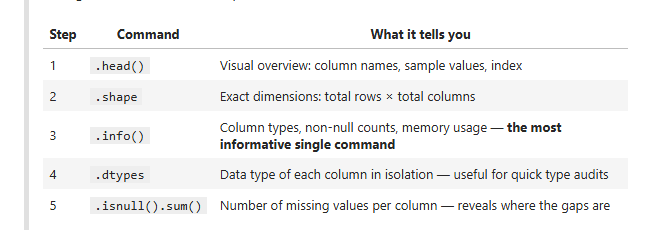

In [4]:

#step 1

(
    pd.read_csv(path_1)
    .head()
)

,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150.0,"$67,965.56"
1,house,Nuevo León,25.688436,-100.198807,186.0,"$63,223.78"
2,apartment,Guerrero,16.767704,-99.764383,82.0,"$84,298.37"
3,apartment,Guerrero,16.829782,-99.911012,150.0,"$94,308.80"
4,house,Veracruz de Ignacio de la Llave,NaN,NaN,175.0,"$94,835.67"


In [5]:
#step 2
(
    pd.read_csv(path_1)
    .shape
)

(700, 6)

In [6]:
#step 3
(
    pd.read_csv(path_1)
    .info
)

<bound method DataFrame.info of     property_type                            state        lat         lon  \
0           house                 Estado de México  19.560181  -99.233528   
1           house                       Nuevo León  25.688436 -100.198807   
2       apartment                         Guerrero  16.767704  -99.764383   
3       apartment                         Guerrero  16.829782  -99.911012   
4           house  Veracruz de Ignacio de la Llave        NaN         NaN   
..            ...                              ...        ...         ...   
695         house                          Morelos        NaN         NaN   
696         house                          Yucatán  21.050653  -89.558841   
697         house                          Yucatán  21.343796  -89.262060   
698     apartment                       Nuevo León        NaN         NaN   
699         house                        Querétaro  20.587378 -100.418361   

     area_m2    price_usd  
0      150.0   

In [7]:
# Step 4
(
    pd.read_csv(path_1)
    .dtypes
)

property_type     object
state             object
lat              float64
lon              float64
area_m2          float64
price_usd         object
dtype: object

In [8]:
#step 5
(
    pd.read_csv(path_1)
    .isnull()
)

,property_type,state,lat,lon,area_m2,price_usd
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,True,True,False,False
...,...,...,...,...,...,...
695,False,False,True,True,False,False
696,False,False,False,False,False,False
697,False,False,False,False,False,False
698,False,False,True,True,False,False


In [9]:
#step 6
(
    pd.read_csv(path_1)
    .isnull()
    .sum()
)

property_type      0
state              0
lat              117
lon              117
area_m2            0
price_usd          0
dtype: int64

In [10]:
#step 7
(
    pd.read_csv(path_1)
    .dropna()
    .shape #Removes rows where values are missing
    
)

(583, 6)

In [11]:
# Step 2: The Complete Chain: After inspection Ritual
df1 = (
    pd.read_csv(path_1)
    # 1. Drop rows with missing critical data
    .dropna()
    
    # 2. Create clean numeric columns using `.assign()`
    # We use 'lambda x' to refer to the data at this specific step in the chain
    # We overwrite 'price_usd' by accessing the current df (x in our lambda function) and cleaning the string
    .assign(
        price_usd = lambda x: x["price_usd"]
                          .str.replace("$", "", regex=False)
                          .str.replace(",", "", regex=False)
                          .astype(float)
                          
    )
)

In [12]:
df1.shape

(583, 6)

In [13]:
#Check for the sum of missing values which should return only zero
df1.isnull().sum().sum()

np.int64(0)

In [15]:
# cleaning process using method chaining
df2 = (
    pd.read_csv(path_2)

     # Create "price_usd" column (19 pesos to the dollar in 2014)
    .assign(price_usd = lambda x: x["price_mxn"].div(19))

    # Drop "price_mxn" column
    .drop(columns=["price_mxn"])

    # Drop null values
    .dropna()
)

# Print object type, shape, and head
print(f"df2 type: {type(df2)}")
print(f"df2 shape: {df2.shape}")
df2.head()

df2 type: <class 'pandas.core.frame.DataFrame'>
df2 shape: (571, 6)


,property_type,state,lat,lon,area_m2,price_usd
0,apartment,Nuevo León,25.721081,-100.345581,72.0,68421.052632
2,house,Morelos,23.634501,-102.552788,360.0,278947.368421
6,apartment,Estado de México,19.272040,-99.572013,85.0,65789.473684
7,house,San Luis Potosí,22.138882,-100.996510,158.0,111578.947368
8,apartment,Distrito Federal,19.394558,-99.129707,65.0,39904.736842


In [ ]:
df2.columns.tolist()  #compare list one to list 2
df1.columns.tolist()
df2["price_usd"].dtype  # Check price_usd data type
df2.isnull().sum()   # check the sum of of empty columns which shouhld be zero

property_type    0
state            0
lat              0
lon              0
area_m2          0
price_usd        0
dtype: int64

In [17]:
df1.columns.tolist()

['property_type', 'state', 'lat', 'lon', 'area_m2', 'price_usd']

In [23]:
(
    pd.read_csv(path_3)
    .head()
)

,property_type,place_with_parent_names,lat-lon,area_m2,price_usd
0,apartment,|México|Distrito Federal|Gustavo A. Madero|Acu...,"19.52589,-99.151703",71.0,48550.59
1,house,|México|Estado de México|Toluca|Metepec|,"19.2640539,-99.5727534",233.0,168636.73
2,house,|México|Estado de México|Toluca|Toluca de Lerd...,"19.268629,-99.671722",300.0,86932.69
3,house,|México|Morelos|Temixco|Burgos Bugambilias|,NaN,275.0,263432.41
4,apartment,|México|Veracruz de Ignacio de la Llave|Veracruz|,"19.511938,-96.871956",84.0,68508.67


In [24]:
(
    pd.read_csv(path_3)
    ["lat-lon"]
    .head()
)

0       19.52589,-99.151703
1    19.2640539,-99.5727534
2      19.268629,-99.671722
3                       NaN
4      19.511938,-96.871956
Name: lat-lon, dtype: object

In [ ]:
(
    pd.read_csv(path_3)
    ["lat-lon"]
    .str.split(",", expand = True)
    .astype(float)
    .head()
)

,0,1
0,19.52589,-99.151703
1,19.2640539,-99.5727534
2,19.268629,-99.671722
3,NaN,NaN
4,19.511938,-96.871956


In [34]:
(
    pd.read_csv(path_3)
    ["place_with_parent_names"]
    .str.split("|", expand = True)
    .head()
)

,0,1,2,3,4,5,6
0,,México,Distrito Federal,Gustavo A. Madero,Acueducto de Guadalupe,,None
1,,México,Estado de México,Toluca,Metepec,,None
2,,México,Estado de México,Toluca,Toluca de Lerdo,Ocho Cedros,
3,,México,Morelos,Temixco,Burgos Bugambilias,,None
4,,México,Veracruz de Ignacio de la Llave,Veracruz,,None,None


In [37]:
# cleaning process using method chaining
df3 = (
    pd.read_csv(path_3)
    # Drop null values from df3
    .dropna()
    # Create "lat" and "lon" columns for df3
    .assign(lat=lambda x: x["lat-lon"]
                .str.split(",", expand=True)[0]           
                .astype(float),
            lon=lambda x: x["lat-lon"]
                .str.split(",", expand=True)[1]           
                .astype(float),
            # Create "state" column for df3
            state=lambda x: x["place_with_parent_names"]
            .str.split("|", expand=True)[2]
           )
    
    # Drop "place_with_parent_names" and "lat-lon" from df3
    .drop(columns=["place_with_parent_names", "lat-lon"])
            
    
)

# Print object type, shape, and head
print("df3 type:", type(df3))
print("df3 shape:", df3.shape)
df3.head()

df3 type: <class 'pandas.core.frame.DataFrame'>
df3 shape: (582, 6)


,property_type,area_m2,price_usd,lat,lon,state
0,apartment,71.0,48550.59,19.525890,-99.151703,Distrito Federal
1,house,233.0,168636.73,19.264054,-99.572753,Estado de México
2,house,300.0,86932.69,19.268629,-99.671722,Estado de México
4,apartment,84.0,68508.67,19.511938,-96.871956,Veracruz de Ignacio de la Llave
5,house,175.0,102763.00,20.689157,-103.366728,Jalisco


In [38]:
# Check if all column sets are identical
columns_match = set(df1) == set(df2) == set(df3)

if columns_match:
    print("✅ All DataFrames have the same columns.")
else:
    print("❌ Column mismatch detected!")
    # Optional: See the difference
    print("df1 vs df2 diff:", set(df1.columns) ^ set(df2.columns))
    print("df2 vs df3 diff:", set(df2.columns) ^ set(df3.columns))

✅ All DataFrames have the same columns.


In [40]:
# Stack df1, df2, and df3 vertically
df = pd.concat([df1, df2, df3], ignore_index=True)
# Verify the result
print(f"Combined Shape: {df.shape}")
df.head()

Combined Shape: (1736, 6)


,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37


In [ ]:
pd

1736

In [42]:
# Stack df1, df2, and df3 vertically
df = pd.concat([df1, df2, df3], ignore_index=True)
# Verify the result
print(f"Combined Shape: {df.shape}")
df.head()

Combined Shape: (1736, 6)


,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37


In [43]:
# Save your cleaned combined dataset
df.to_csv("./data/mexico-real-estate-combined-clean.csv", index=False)

In [44]:
# Summarize the numeric columns
summary = df[["price_usd", "area_m2"]].describe()

# # Format for readability
pd.options.display.float_format = '{:,.2f}'.format

summary

,price_usd,area_m2
count,"1,736.00","1,736.00"
mean,"115,331.98",170.26
std,"65,426.17",80.59
min,"33,157.89",60.00
25%,"65,789.47",101.75
50%,"99,262.13",156.00
75%,"150,846.66",220.00
max,"326,733.66",385.00


In [45]:
df.describe()

,lat,lon,area_m2,price_usd
count,"1,736.00","1,736.00","1,736.00","1,736.00"
mean,20.77,-98.80,170.26,"115,331.98"
std,2.74,4.88,80.59,"65,426.17"
min,15.75,-117.05,60.00,"33,157.89"
25%,19.28,-100.39,101.75,"65,789.47"
50%,19.62,-99.20,156.00,"99,262.13"
75%,21.07,-98.25,220.00,"150,846.66"
max,32.67,-86.77,385.00,"326,733.66"
